In [14]:
import datetime
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm
import kagglehub
import os
import PIL

In [2]:
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)
print("numpy version : ", np.__version__)

!python --version

torch version :  2.11.0+cpu
torchvision version :  0.26.0+cpu
numpy version :  2.0.2
Python 3.12.13


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Loading Data

In [4]:
# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [5]:
!ls -l /kaggle/input/brain-tumor-mri-dataset

total 0
drwxr-sr-x 6 1000 1000 0 Feb 13 20:27 Testing
drwxr-sr-x 6 1000 1000 0 Feb 13 20:27 Training


In [7]:
!cd /kaggle/input/brain-tumor-mri-dataset/Training

In [9]:
!ls -l /kaggle/input/brain-tumor-mri-dataset/Training

total 0
drwxr-sr-x 2 1000 1000 0 Feb 13 20:27 glioma
drwxr-sr-x 2 1000 1000 0 Feb 13 20:27 meningioma
drwxr-sr-x 2 1000 1000 0 Feb 13 20:27 notumor
drwxr-sr-x 2 1000 1000 0 Feb 13 20:27 pituitary


In [11]:
train_dir = Path("/kaggle/input/brain-tumor-mri-dataset/Training")

In [12]:
def sample_images(data_path, classname):
    # Gets the files in the directory
    class_dir = os.path.join(data_path, classname)
    if not os.path.exists(class_dir):
        return "Invalid directory"
    image_list = os.listdir(class_dir)
    if len(image_list) < 4:
        return "Not enough images in folder"

    # Pick four random images
    images_sample = random.sample(image_list, 4)

    # Plot them
    plt.figure(figsize=(20, 20))
    for i in range(4):
        img_loc = os.path.join(class_dir, images_sample[i])
        img = PIL.Image.open(img_loc)
        plt.subplot(1, 4, i + 1)
        plt.imshow(img)
        plt.axis("off")

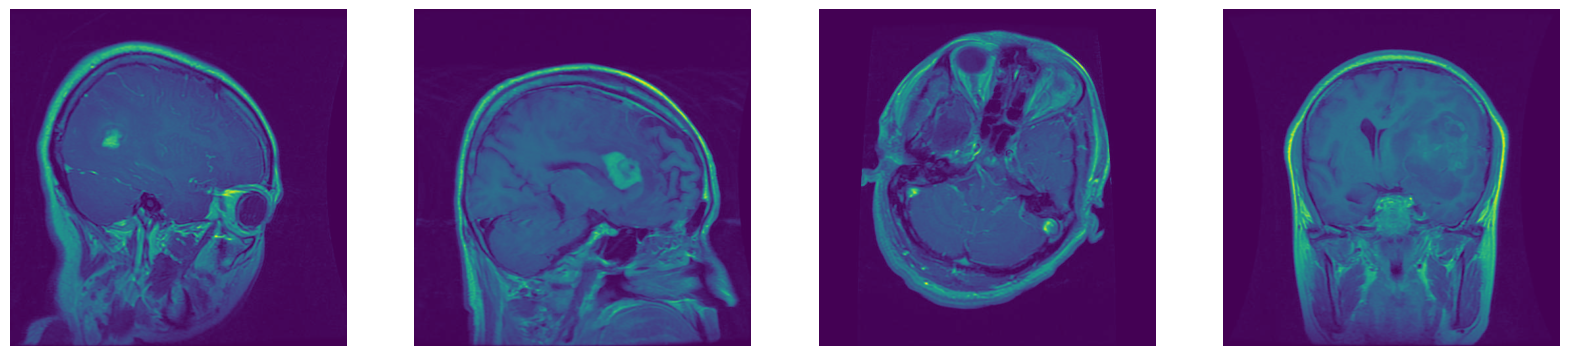

In [15]:
sample_images(train_dir, "glioma")

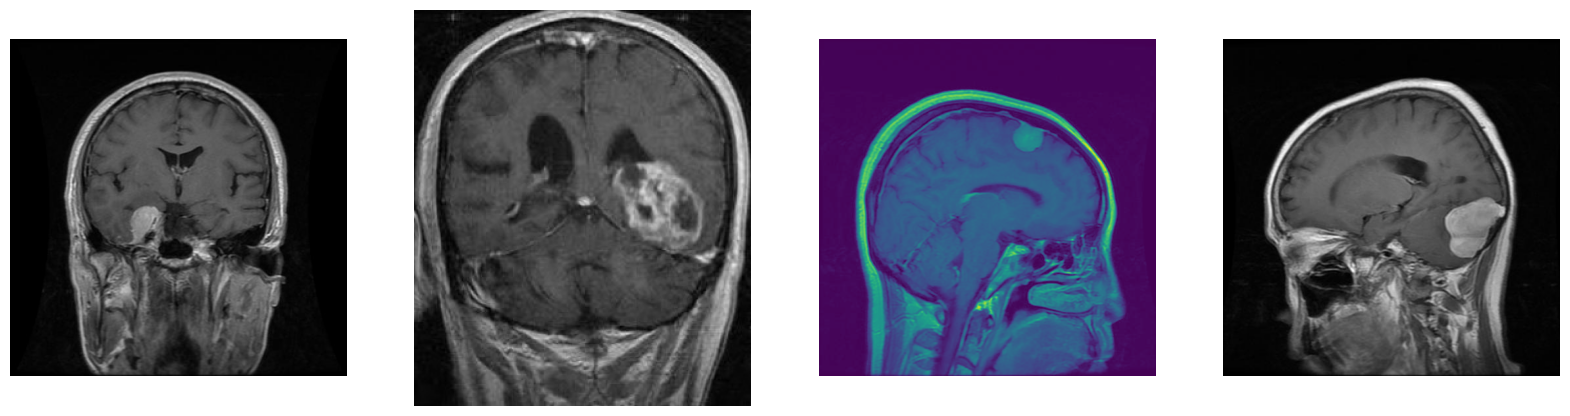

In [16]:
sample_images(train_dir, "meningioma")

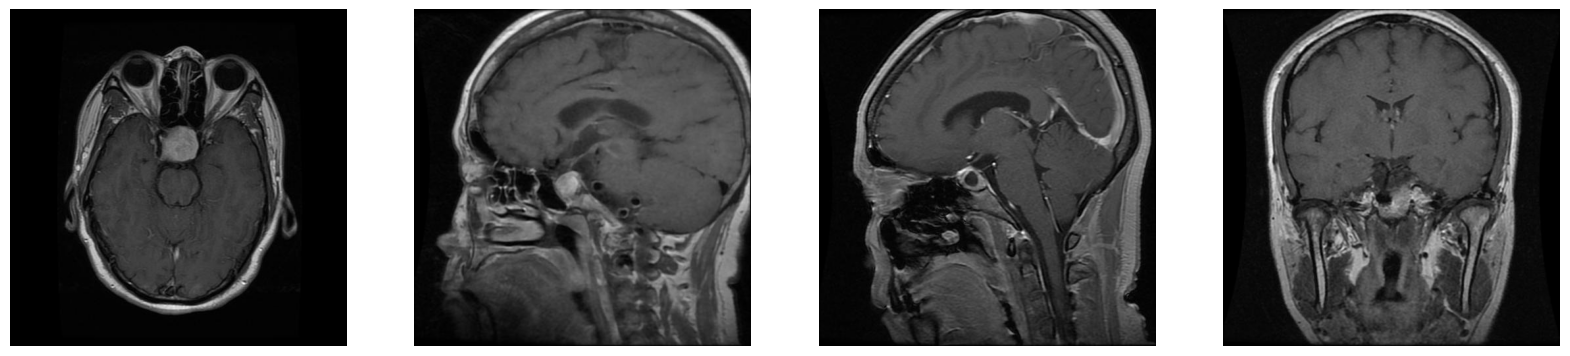

In [17]:
sample_images(train_dir, "pituitary")

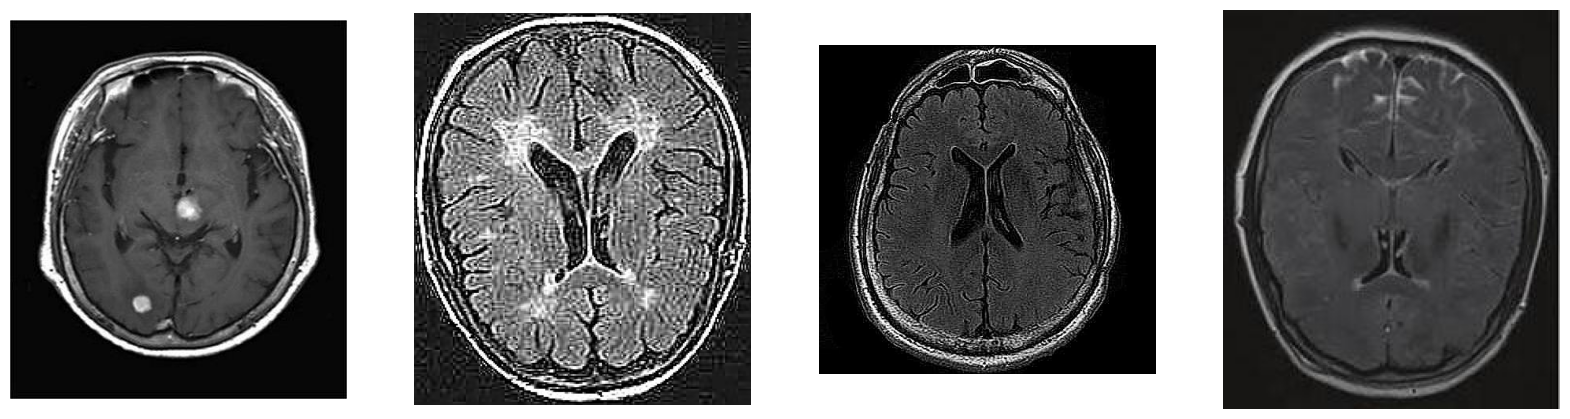

In [18]:
sample_images(train_dir, "notumor")

In [25]:
len_0 = len(os.listdir(train_dir / "glioma"))
len_1 = len(os.listdir(train_dir / "notumor"))
len_2 = len(os.listdir(train_dir / "pituitary"))
len_3 = len(os.listdir(train_dir / "meningioma"))

print(f"Number of images in glioma folder: {len_0}")
print(f"Number of images in notumor folder: {len_1}")
print(f"Number of images in pituitary folder: {len_2}")
print(f"Number of images in meningioma folder: {len_3}")

Number of images in glioma folder: 1400
Number of images in notumor folder: 1400
Number of images in pituitary folder: 1400
Number of images in meningioma folder: 1400


In [26]:
test_dir = Path("/kaggle/input/brain-tumor-mri-dataset/Testing")

len_0 = len(os.listdir(test_dir / "glioma"))
len_1 = len(os.listdir(test_dir / "notumor"))
len_2 = len(os.listdir(test_dir / "pituitary"))
len_3 = len(os.listdir(test_dir / "meningioma"))

print(f"Number of images in glioma folder: {len_0}")
print(f"Number of images in notumor folder: {len_1}")
print(f"Number of images in pituitary folder: {len_2}")
print(f"Number of images in meningioma folder: {len_3}")


Number of images in glioma folder: 400
Number of images in notumor folder: 400
Number of images in pituitary folder: 400
Number of images in meningioma folder: 400


# Strategy For GANs

1. One Hot Encode the classes {0, 1, 2, 3}

2. Join The Train and Test Images to have more Image Data

3. The images have different Colour Channel we need to GrayScale during transformation